<a href="https://colab.research.google.com/github/connerbevan/Random-Personal-Projects/blob/main/household_power_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Household Electric Power Consumption Analysis

## Question
When does a single household use the most electricity, and how do daily and seasonal patterns differ?

## Why this dataset
I'm an electrical and computer engineering student, and I wanted a project that connects to something real in my field: how electricity actually gets used. This dataset lets me look at one home's load over almost four years and see what drives changes in demand, like time of day and season.

## Data
Individual Household Electric Power Consumption (Hebrail & Berard, UCI Machine Learning Repository). It has roughly 2 million one-minute readings from one home near Paris, France, from December 2006 to November 2010. It includes active and reactive power, voltage, current, and three sub-meters:
- Sub-meter 1: kitchen
- Sub-meter 2: laundry room
- Sub-meter 3: water heater and air conditioner

Since this is a single household, I'm treating the results as a case study, not as a picture of how everyone uses power.

## What I did
1. Cleaned the data (missing values were stored as `?`, so I had to convert the columns before I could find them)
2. Built a timestamp index
3. Looked at patterns by hour, weekday vs. weekend, and month
4. Investigated an anomaly I noticed in August 2008
5. Compared the three sub-meters with the unmetered consumption

In [27]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt

data = fetch_ucirepo(id=235)
df = data.data.features.copy()
df.head()

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [28]:
num_cols = ["Global_active_power", "Global_reactive_power", "Voltage",
            "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [29]:
print(df.isnull().sum())
print((df.isnull().mean() * 100).round(2))

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Date                     0.00
Time                     0.00
Global_active_power      1.25
Global_reactive_power    1.25
Voltage                  1.25
Global_intensity         1.25
Sub_metering_1           1.25
Sub_metering_2           1.25
Sub_metering_3           1.25
dtype: float64


In [30]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
df = df.set_index("datetime").sort_index()
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


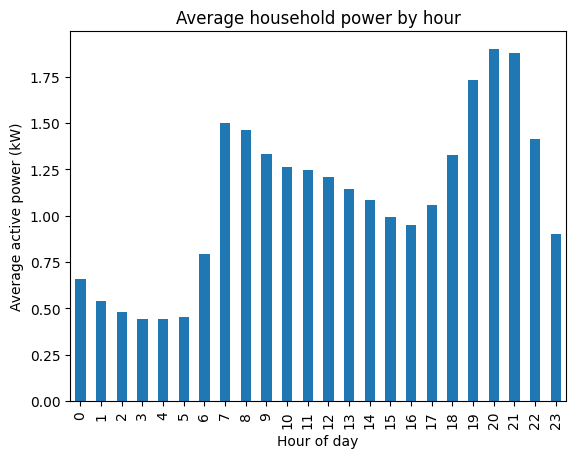

In [31]:
hourly = df.groupby(df.index.hour)["Global_active_power"].mean()
hourly.plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Average active power (kW)")
plt.title("Average household power by hour")
plt.show()

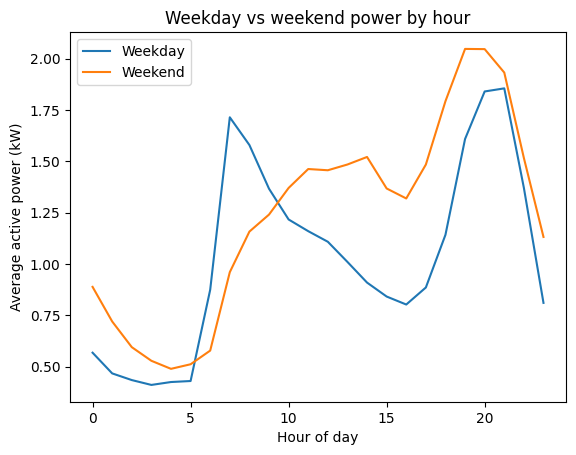

In [32]:
weekday = df[df.index.dayofweek < 5].groupby(df[df.index.dayofweek < 5].index.hour)["Global_active_power"].mean()
weekend = df[df.index.dayofweek >= 5].groupby(df[df.index.dayofweek >= 5].index.hour)["Global_active_power"].mean()

plt.plot(weekday, label="Weekday")
plt.plot(weekend, label="Weekend")
plt.xlabel("Hour of day")
plt.ylabel("Average active power (kW)")
plt.title("Weekday vs weekend power by hour")
plt.legend()
plt.show()

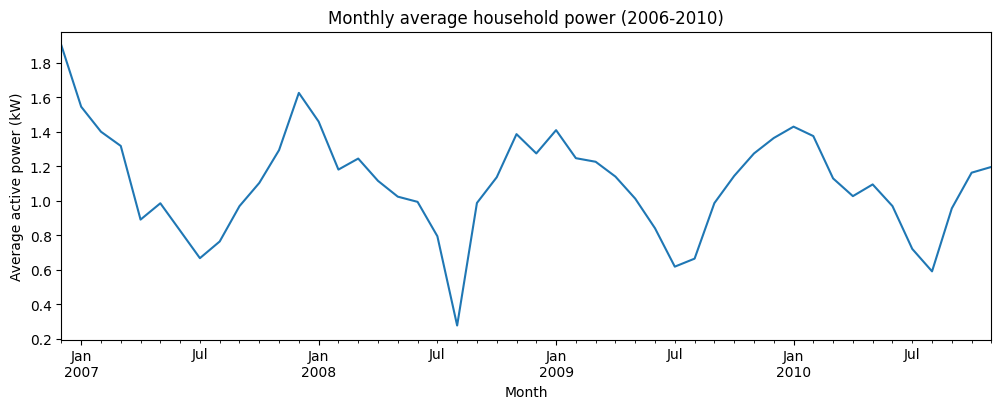

In [33]:
monthly = df["Global_active_power"].resample("ME").mean()
monthly.plot(figsize=(12, 4))
plt.xlabel("Month")
plt.ylabel("Average active power (kW)")
plt.title("Monthly average household power (2006-2010)")
plt.show()

In [34]:
missing_by_month = df["Global_active_power"].isnull().resample("ME").mean() * 100
print(missing_by_month.round(1).loc["2008-06":"2008-10"])

datetime
2008-06-30    0.0
2008-07-31    0.0
2008-08-31    0.0
2008-09-30    0.0
2008-10-31    0.1
Freq: ME, Name: Global_active_power, dtype: float64


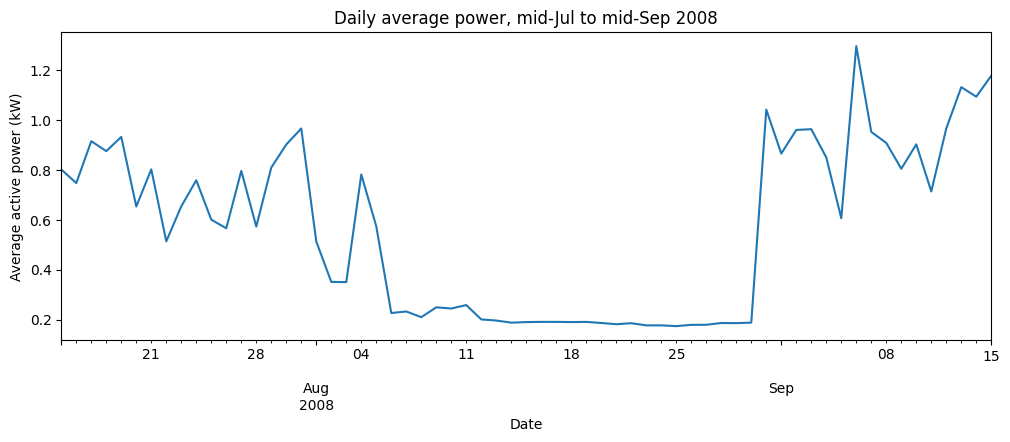

In [35]:
daily = df["Global_active_power"].resample("D").mean()
daily.loc["2008-07-15":"2008-09-15"].plot(figsize=(12, 4))
plt.xlabel("Date")
plt.ylabel("Average active power (kW)")
plt.title("Daily average power, mid-Jul to mid-Sep 2008")
plt.show()

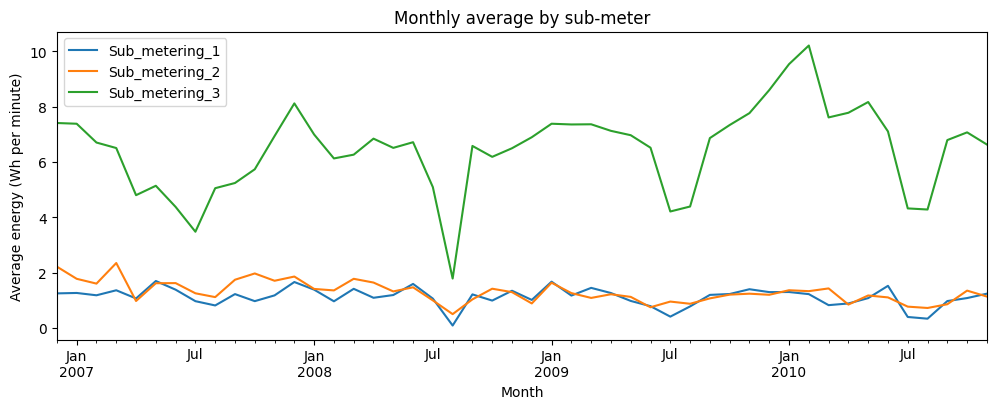

In [36]:
sub = df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].resample("ME").mean()
sub.plot(figsize=(12, 4))
plt.xlabel("Month")
plt.ylabel("Average energy (Wh per minute)")
plt.title("Monthly average by sub-meter")
plt.show()

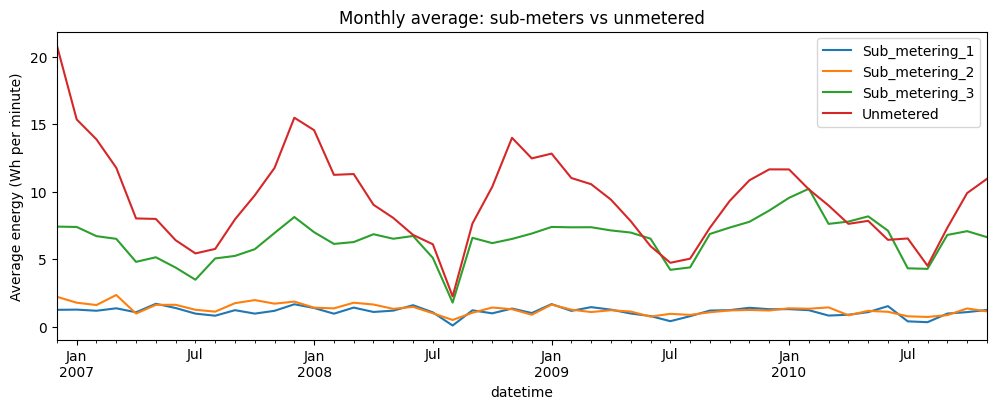

In [37]:
df["Unmetered"] = df["Global_active_power"] * 1000 / 60 - df["Sub_metering_1"] - df["Sub_metering_2"] - df["Sub_metering_3"]
compare = df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "Unmetered"]].resample("ME").mean()
compare.plot(figsize=(12, 4))
plt.ylabel("Average energy (Wh per minute)")
plt.title("Monthly average: sub-meters vs unmetered")
plt.show()

## Conclusions

**Daily pattern:** The household's power use is lowest overnight (about 0.45 kW) and climbs through the morning. It peaks in the evening at about 1.9 kW, around 7-9 PM. I expected a shape like this, but seeing the small morning peak and bigger evening peak in real data made it click for me as a typical residential load profile. I'd guess the evening peak comes from cooking dinner, running multiple appliances, and people relaxing with TV or video games. The smaller morning peak is probably people getting ready for the day.

**Weekday vs. weekend:** On weekdays I found a sharp spike around 7 AM, then a lower daytime, which looks like everyone leaving for the day. Weekends start later and stay higher through midday, which fits people being home. What surprised me most was how sharp the weekday 7 AM spike is. I expected a morning increase from people waking up, but not one that narrow, and it drops off quickly afterward.

**Seasonality:** Usage is highest in winter and lowest in summer, and the cycle repeats in all four years. My guess is heating and shorter days, though I can't prove that from this data alone.

**August 2008 anomaly:** This was the part I found most interesting. August 2008 was far lower than every other summer, so I checked whether missing data caused it. It didn't (0.0% missing). Daily averages then showed a flat ~0.2 kW block lasting about three weeks. A lived-in home has daily ups and downs, so a flat line suggests nobody was home and only always-on devices like the fridge were running. That's my inference, not something I can confirm, but it also gives me a rough estimate of the home's baseline standby load.

**What drives the seasonal swing:** I expected the water heater/AC sub-meter to explain most of the winter increase. It's the largest metered load and does rise in winter, but the unmetered load (everything not on the three sub-meters) is larger and swings more. I can't tell what's in that category from this data, so anything I say about it, like electric heating, is only a hypothesis.

## Limitations
- This is one household in France, so I can't say the patterns apply to other homes.
- About 1.25% of rows were missing, and my averages skip them.
- The first and last months are partial, so I ignored the first data point on the monthly charts.
- I can't break the unmetered category down any further.

## What I'd do next
- Build a model to forecast next-day usage for this household
- Find similar datasets from other places and compare how usage patterns differ
- Compare warmer and colder climates to see how heating and cooling change the daily and seasonal shapes